In [9]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
dataset_path = kagglehub.dataset_download('puneet6060/intel-image-classification')

print('Data source import complete.')


Using Colab cache for faster access to the 'intel-image-classification' dataset.
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
/kaggle/input/intel-image-classification/seg_pred/seg_pred/20481.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/14977.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/8763.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/12099.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/21131.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/4572.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/20412.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/13620.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/10052.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/17167.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/6348.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/5645.jpg
/kaggle/input/intel-image-classification/seg_pred/seg_pred/389.jpg
/kaggle/input/intel-image-classification/seg_pred/se

In [1]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

## Check GPU

In [6]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Using: cuda


In [10]:
import os

print(dataset_path)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)

    if level > 2:
        continue

    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:3]:
        print(f"{indent}    {file}")

/kaggle/input/intel-image-classification
intel-image-classification/
    seg_train/
        seg_train/
    seg_pred/
        seg_pred/
            6234.jpg
            22288.jpg
            20529.jpg
    seg_test/
        seg_test/


In [11]:
TRAIN_DIR = os.path.join(
    dataset_path,
    "seg_train",
    "seg_train"
)

VAL_DIR = os.path.join(
    dataset_path,
    "seg_test",
    "seg_test"
)

print(TRAIN_DIR)
print(VAL_DIR)

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Val exists:", os.path.exists(VAL_DIR))

/kaggle/input/intel-image-classification/seg_train/seg_train
/kaggle/input/intel-image-classification/seg_test/seg_test
Train exists: True
Val exists: True


## Config

In [33]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 15

NUM_WORKERS = 2
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Preprocess

In [13]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.8, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize(232),
    transforms.CenterCrop(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [14]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)

num_classes = len(train_dataset.classes)

print("Classes:")
print(train_dataset.classes)

print("\nNumber of classes:", num_classes)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Number of classes: 6
Train images: 14034
Validation images: 3000


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [17]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [20]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [21]:
in_features = model.fc.in_features

model.fc = nn.Linear(
    in_features,
    num_classes
)

print(model.fc)

model = model.to(device)

Linear(in_features=2048, out_features=6, bias=True)


In [22]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

## Traning

In [24]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Xóa gradient cũ
        optimizer.zero_grad()

        # Forward
        logits = model(images)

        # Loss
        loss = criterion(
            logits,
            labels
        )

        # Backward
        loss.backward()

        # Update
        optimizer.step()

        batch_size = images.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

## Validation

In [25]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        batch_size = images.size(0)

        total_loss += (
            loss.item() * batch_size
        )

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [31]:
def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    device,
    patience=3
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    epochs_without_improvement = 0

    start_time = time.perf_counter()

    for epoch in range(epochs):

        # =====================
        # Train
        # =====================
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        # =====================
        # Validation
        # =====================
        val_loss, val_acc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # =====================
        # Early stopping logic
        # =====================
        if val_acc > best_val_acc:

            best_val_acc = val_acc

            best_weights = copy.deepcopy(
                model.state_dict()
            )

            # Có improvement
            epochs_without_improvement = 0

        else:

            # Không improvement
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Patience: {epochs_without_improvement}/{patience}"
        )

        # =====================
        # Stop
        # =====================
        if epochs_without_improvement >= patience:
            print(
                f"\nEarly stopping at epoch {epoch+1}"
            )
            break

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    # Quay lại model tốt nhất
    model.load_state_dict(best_weights)

    return model, history, elapsed_time

In [32]:
# warm-up
model, history_head, time_head = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=HEAD_EPOCHS,
    device=device
)

print(
    f"Head training time: "
    f"{time_head:.2f} seconds"
)

Epoch 01/3 | Train Loss: 0.2440 | Train Acc: 0.9160 | Val Loss: 0.2287 | Val Acc: 0.9157 | Patience: 0/3
Epoch 02/3 | Train Loss: 0.2395 | Train Acc: 0.9142 | Val Loss: 0.2253 | Val Acc: 0.9187 | Patience: 0/3
Epoch 03/3 | Train Loss: 0.2276 | Train Acc: 0.9189 | Val Loss: 0.2265 | Val Acc: 0.9150 | Patience: 1/3
Head training time: 204.29 seconds


In [35]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [38]:
#fine-tune
trainable_params = [
    name
    for name, param in model.named_parameters()
    if param.requires_grad
]

print("Number of trainable parameter tensors:")
print(len(trainable_params))

print("\nFirst few:")
for name in trainable_params[:20]:
    print(name)

Number of trainable parameter tensors:
32

First few:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight


In [39]:
optimizer = torch.optim.AdamW([
    {
        "params": model.layer4.parameters(),
        "lr": 1e-4
    },
    {
        "params": model.fc.parameters(),
        "lr": 1e-3
    }
],
weight_decay=1e-4)

In [40]:
model, history_ft, time_ft = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=FINETUNE_EPOCHS,
    device=device
)

print(
    f"Fine-tuning time: "
    f"{time_ft:.2f} seconds"
)

Epoch 01/15 | Train Loss: 0.2140 | Train Acc: 0.9212 | Val Loss: 0.1815 | Val Acc: 0.9353 | Patience: 0/3
Epoch 02/15 | Train Loss: 0.1493 | Train Acc: 0.9463 | Val Loss: 0.1930 | Val Acc: 0.9317 | Patience: 1/3
Epoch 03/15 | Train Loss: 0.1095 | Train Acc: 0.9590 | Val Loss: 0.1898 | Val Acc: 0.9317 | Patience: 2/3
Epoch 04/15 | Train Loss: 0.0806 | Train Acc: 0.9701 | Val Loss: 0.2010 | Val Acc: 0.9290 | Patience: 3/3

Early stopping at epoch 4
Fine-tuning time: 300.48 seconds


In [42]:
history = {}

for key in history_head.keys():
    history[key] = (
        history_head[key]
        + history_ft[key]
    )

total_time = time_head + time_ft

print(
    f"Total training time: "
    f"{total_time:.2f} seconds"
)

Total training time: 502.31 seconds


## Plot learning curves

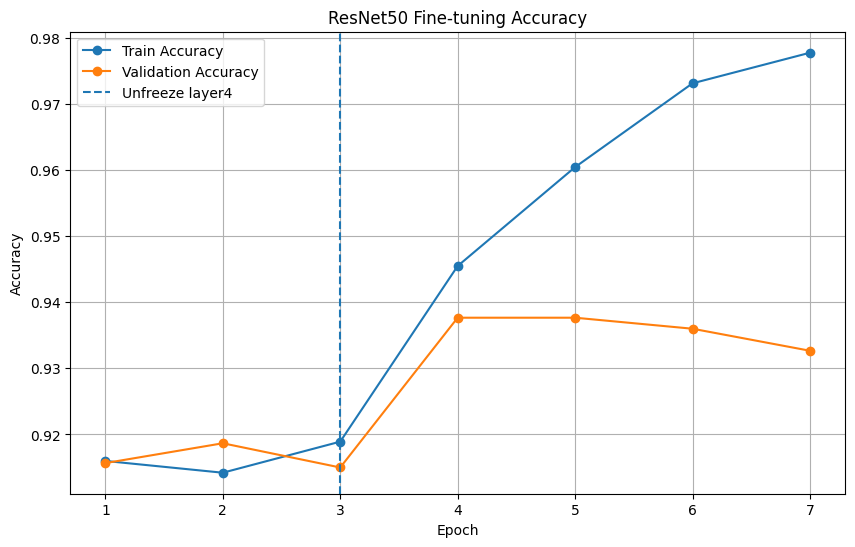

In [43]:
epochs = range(
    1,
    len(history["train_acc"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_acc"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.axvline(
    x=HEAD_EPOCHS,
    linestyle="--",
    label="Unfreeze layer4"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Fine-tuning Accuracy")

plt.legend()
plt.grid()

plt.show()

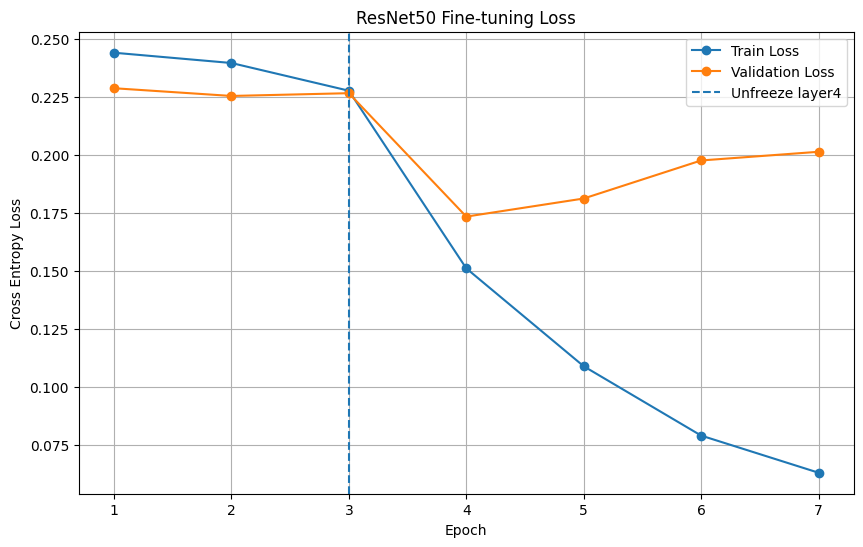

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.axvline(
    x=HEAD_EPOCHS,
    linestyle="--",
    label="Unfreeze layer4"
)

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("ResNet50 Fine-tuning Loss")

plt.legend()
plt.grid()

plt.show()

In [45]:
best_epoch = (
    np.argmax(history["val_acc"])
    + 1
)

best_val_acc = max(
    history["val_acc"]
)

print(
    f"Best validation accuracy: "
    f"{best_val_acc * 100:.2f}%"
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Total training time: "
    f"{total_time:.2f}s"
)

Best validation accuracy: 93.77%
Best epoch: 4
Total training time: 502.31s
